In [5]:
import sys
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 确保 src/ 包可被导入
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, root_dir)

from config import COAL_TYPES, TRAIN_DIR, TEST_DIR, AUX_COLS, ALPHAS
from src.data   import load_labels, load_coal_spectra
from src.submit import pack_submission
from src.model import get_cv_splits
from src.features import build_feature_matrix
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

In [3]:
label_map, aux_map = load_labels()
coal_type = COAL_TYPES[0]
train_data = load_coal_spectra(TRAIN_DIR, coal_type, label_map, aux_map)

y          = train_data['targets']
aux        = train_data['aux']
n_batches = train_data['n_batches']
groups  = train_data['groups']

splits = get_cv_splits(groups, n_batches)
X_spec, scaler_spec, pca, scaler_hand = build_feature_matrix(
        train_data, n_batches, fit=True)

In [8]:
# ── Stage 1: 光谱 → 辅助指标 (OOF) ────────────────────────────────────
aux_models        = {}
predicted_aux_oof = np.zeros_like(aux, dtype=np.float32)
for col_idx, col_name in enumerate(AUX_COLS):
    y_aux = aux[:, col_idx]

    # 辅助指标有缺失时退化为用均值填充
    if np.isnan(y_aux).any():
        predicted_aux_oof[:, col_idx] = float(np.nanmean(y_aux))
        aux_models[col_name] = None
        continue

    m = RidgeCV(alphas=ALPHAS)
    oof = np.zeros(len(y_aux))
    # Foldwise model for intermediate prediction
    for tr_idx, val_idx in splits:
        m.fit(X_spec[tr_idx], y_aux[tr_idx])
        oof[val_idx] = m.predict(X_spec[val_idx])
    predicted_aux_oof[:, col_idx] = oof

    m.fit(X_spec, y_aux)   # 全量重新拟合，存入 aux_models 供推理用
    aux_models[col_name] = m

    # Diagnostic
    rmse = np.sqrt(np.mean((oof - y_aux) ** 2))
    print(f"Aux variable {col_name}")
    print(f"  RMSE: {rmse: .4f}")
    print(f"  Percentage error: {rmse / np.mean(y_aux) * 100: .2f}%")

# ── Stage 2: [光谱特征 + 预测辅助指标] → 发热量 ──────────────────────

X_s2      = np.hstack((X_spec, predicted_aux_oof))
scaler_s2 = StandardScaler()
X_s2      = scaler_s2.fit_transform(np.nan_to_num(X_s2))

# OOF 批次预测（用于计算 CV-RMSE 和收缩权重）
oof_cv = np.zeros_like(y)
oof_batch_preds, oof_batch_true, batch_rmses = [], [], []

for tr_idx, val_idx in splits:
    m2 = RidgeCV(alphas=ALPHAS)
    m2.fit(X_s2[tr_idx], y[tr_idx])
    val_pred   = m2.predict(X_s2[val_idx])
    oof_cv[val_idx] = val_pred
    val_groups = groups[val_idx]

    fold_se = []
    for bg in np.unique(val_groups):
        mask   = val_groups == bg
        true_q = float(y[val_idx][mask][0])
        pred_q = float(np.median(val_pred[mask]))
        oof_batch_preds.append(pred_q)
        oof_batch_true.append(true_q)
        fold_se.append((true_q - pred_q) ** 2)
    batch_rmses.append(float(np.sqrt(np.mean(fold_se))))

Aux variable 全水分
  RMSE:  1.4306
  Percentage error:  15.38%
Aux variable 灰分
  RMSE:  3.9818
  Percentage error:  18.28%
Aux variable 氢
  RMSE:  0.0872
  Percentage error:  3.83%
Aux variable 硫
  RMSE:  0.0603
  Percentage error:  13.73%


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_batch_distributions(y_shot_pred, shot_batch_ids, y_true_shot, target_name="Calorific Value"):
    """
    Analyzes shot-level prediction distributions alongside true batch targets.
    
    Parameters:
    -----------
    y_shot_pred : 1D array
        Predicted values for each shot from Stage 1.
    shot_batch_ids : 1D array
        Batch IDs corresponding to each shot.
    y_true_shot : 1D array
        True ground truth targets (variable 'y' repeated for each shot in a batch).
    target_name : str
        Name of the target variable for plot axis labels.
    """
    # 1. Build DataFrame
    df = pd.DataFrame({
        'batch_id': shot_batch_ids,
        'pred': y_shot_pred,
        'y_true': y_true_shot
    })
    
    # 2. Compute Batch-Level Statistics
    batch_stats = df.groupby('batch_id').agg(
        pred_mean=('pred', 'mean'),
        pred_std=('pred', 'std'),
        pred_median=('pred', 'median'),
        y_true=('y_true', 'first')  # Since y_true is constant within a batch
    ).reset_index()
    
    # Calculate Coefficient of Variation (std / |mean|)
    batch_stats['cv'] = batch_stats['pred_std'] / np.abs(batch_stats['pred_mean'])
    batch_stats['std_ratio'] = batch_stats['pred_std'] / np.std(y_shot_pred)
    batch_stats['mean_error'] = np.abs(batch_stats['pred_mean'] - batch_stats['y_true'])
    batch_stats['median_error'] = np.abs(batch_stats['pred_median'] - batch_stats['y_true'])

    print(f"=== Intra-Batch Diagnostic Summary ({target_name}) ===")
    print(batch_stats[['pred_mean', 'pred_std', 'cv', 'y_true', 'mean_error']].describe())
    
    # 3. Create Plots
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    
    # Plot A: Intra-Batch Coefficient of Variation
    sns.histplot(batch_stats['cv'], bins=25, ax=axes[0], kde=True, color='navy')
    axes[0].set_title('Intra-Batch Dispersion (Std / Mean)')
    axes[0].set_xlabel('Coefficient of Variation (CV)')
    axes[0].set_ylabel('Number of Batches')
    
    # Plot B: Predicted Batch Mean vs True Batch Label (Colored by Shot Variance)
    scatter = axes[1].scatter(
        batch_stats['y_true'], 
        batch_stats['pred_mean'], 
        c=batch_stats['pred_std'], 
        cmap='viridis', 
        alpha=0.8, 
        edgecolors='k',
        linewidths=0.5
    )
    # Add 1:1 Ideal Line
    min_val = min(batch_stats['y_true'].min(), batch_stats['pred_mean'].min())
    max_val = max(batch_stats['y_true'].max(), batch_stats['pred_mean'].max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (1:1)')
    
    axes[1].set_title(f'Batch Mean vs. True {target_name}')
    axes[1].set_xlabel(f'True {target_name}')
    axes[1].set_ylabel(f'Predicted Batch Mean {target_name}')
    axes[1].legend(loc='upper left')
    cbar = fig.colorbar(scatter, ax=axes[1])
    cbar.set_label('Intra-Batch Std Dev')
    
    # Plot C: Boxplots for Sampled Batches with Ground Truth Overlay (Red Star)
    sample_batch_ids = np.random.choice(
        batch_stats['batch_id'].unique(), 
        size=min(12, len(batch_stats)), 
        replace=False
    )
    df_sample = df[df['batch_id'].isin(sample_batch_ids)]
    
    # Plot shot boxplots and raw shot points
    sns.boxplot(data=df_sample, x='batch_id', y='pred', ax=axes[2], color='lightgray', fliersize=0)
    sns.stripplot(data=df_sample, x='batch_id', y='pred', ax=axes[2], color='royalblue', alpha=0.6, size=5, jitter=0.2)
    
    # Overlay True Batch Label (Red Star) for each sampled batch
    batch_order = list(df_sample['batch_id'].unique())
    for x_idx, b_id in enumerate(batch_order):
        true_val = batch_stats[batch_stats['batch_id'] == b_id]['y_true'].values[0]
        axes[2].scatter(
            x_idx, 
            true_val, 
            color='red', 
            s=130, 
            marker='*', 
            zorder=5, 
            label='True Batch Label' if x_idx == 0 else ""
        )
        
    axes[2].set_title('Shot Predictions vs True Label (Red Star)')
    axes[2].set_xlabel('Batch ID')
    axes[2].set_ylabel(target_name)
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return batch_stats

# --- Example Usage ---
# stats_df = analyze_batch_distributions(
#     y_shot_pred=oof[:, 0], 
#     shot_batch_ids=shot_batch_ids, 
#     y_true_shot=y, 
#     target_name="Calorific Value"
# )

=== Intra-Batch Diagnostic Summary (Calorific Value) ===
         pred_mean    pred_std         cv       y_true  mean_error
count    11.000000   11.000000  11.000000    11.000000   11.000000
mean   5733.899796  131.235882   0.022994  5700.363636  141.543391
std     255.920862   29.807079   0.005548   400.690722  110.310815
min    5080.165527   91.499806   0.015514  4708.000000   19.514461
25%    5639.080335  107.742784   0.018446  5560.500000   59.966128
50%    5829.092640  128.695566   0.022879  5741.000000   98.870831
75%    5863.368703  149.762580   0.027589  5937.000000  199.032776
max    5993.160384  178.606147   0.030584  6143.000000  372.165527


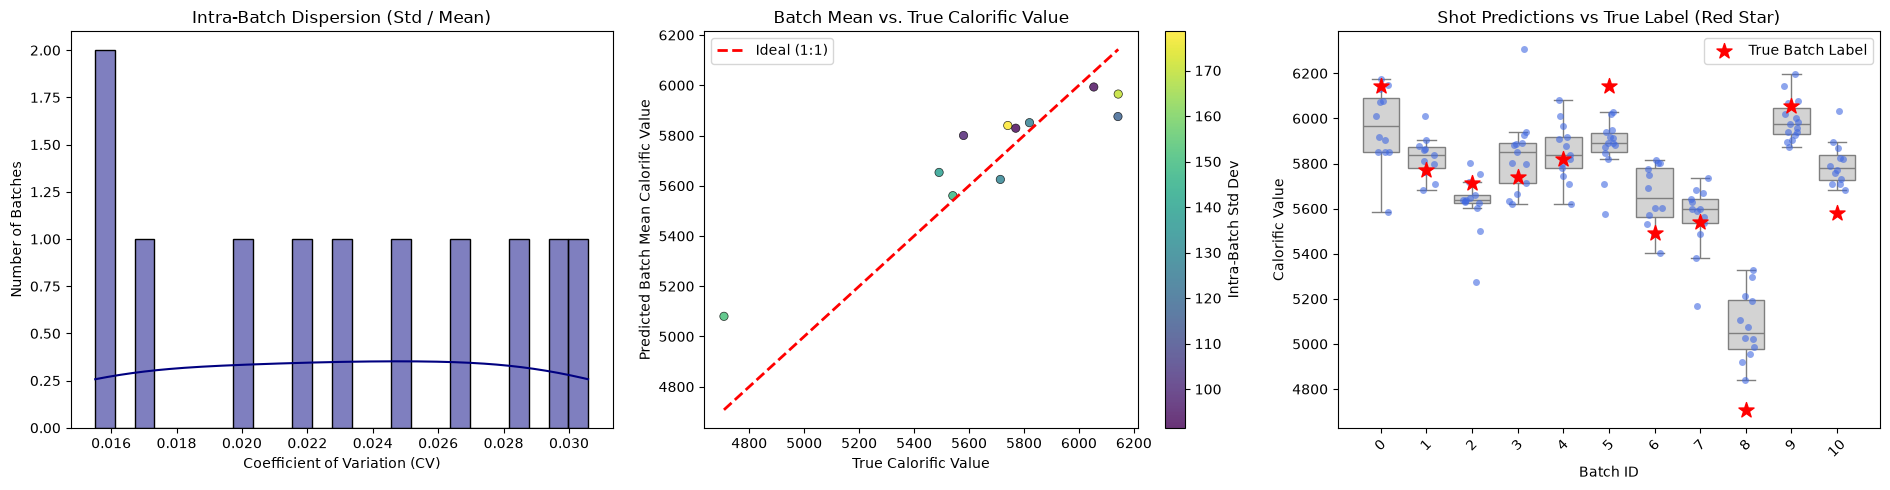

In [25]:
stats_df = analyze_batch_distributions(oof_cv, groups, y)

In [26]:
stats_df

,batch_id,pred_mean,pred_std,pred_median,y_true,cv,std_ratio,mean_error,median_error
0,0,5965.065145,170.406227,5964.434814,6143.0,0.028567,0.623229,177.934855,178.565186
1,1,5829.092640,91.499806,5838.502441,5770.0,0.015697,0.334644,59.092640,68.502441
2,2,5625.150578,128.695566,5637.416992,5714.0,0.022879,0.470680,88.849422,76.583008
3,3,5839.870831,178.606147,5850.116699,5741.0,0.030584,0.653219,98.870831,109.116699
4,4,5851.153283,127.322030,5836.439941,5820.0,0.021760,0.465657,31.153283,16.439941
5,5,5875.584124,117.329834,5890.853760,6142.0,0.019969,0.429112,266.415876,251.146240
6,6,5653.010091,139.075403,5646.852051,5491.0,0.024602,0.508643,162.010091,155.852051
7,7,5560.514461,147.970924,5596.758301,5541.0,0.026611,0.541176,19.514461,55.758301
8,8,5080.165527,151.554237,5050.481445,4708.0,0.029833,0.554282,372.165527,342.481445
9,9,5993.160384,92.978792,5976.545410,6054.0,0.015514,0.340053,60.839616,77.454590


In [29]:
np.corrcoef(stats_df['pred_std'], stats_df['median_error'])

array([[1.        , 0.17911904],
       [0.17911904, 1.        ]])

The error is probably uncorrelated with the within batch variation. So further investigating aggreagation method wil likely to be unfruitful.

In [40]:
# oof_cv: your OOF batch-level predictions; y_cv: true batch-level CV
oof_batch_true = np.array(oof_batch_true)
oof_batch_preds = np.array(oof_batch_preds)
global_mean = np.mean(oof_batch_true)
deviation_from_mean = oof_batch_true - global_mean
error = oof_batch_preds - oof_batch_true

# Is prediction error correlated with how extreme the true value is?
import numpy as np
print(np.corrcoef(deviation_from_mean, error))

# More direct test: regress oof_cv on y_cv. Slope < 1 confirms shrinkage.
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(oof_batch_true.reshape(-1,1), oof_batch_preds)
print("slope:", lr.coef_[0], "intercept:", lr.intercept_)

[[ 1.         -0.88809453]
 [-0.88809453  1.        ]]
slope: 0.618358681280849 intercept: 2208.6696327184677


In [56]:
from sklearn.model_selection import KFold
calibrated_nested = np.zeros_like(oof_batch_preds)

# batch_groups: array mapping each row to its batch/fold group
gkf = KFold(n_splits=5)

for tr_idx, val_idx in gkf.split(oof_batch_preds):
    cal = LinearRegression().fit(
        oof_batch_preds[tr_idx].reshape(-1,1), oof_batch_true[tr_idx]
    )
    calibrated_nested[val_idx] = cal.predict(oof_batch_preds[val_idx].reshape(-1,1))

rmse_nested = np.sqrt(np.mean((calibrated_nested - oof_batch_true)**2))
print(f"RMSE before calibration: {np.sqrt(np.mean((oof_batch_preds - oof_batch_true) ** 2)): .2f}")
print(f"RMSE after NESTED calibration: {rmse_nested:.2f}")

RMSE before calibration:  167.49
RMSE after NESTED calibration: 149.92


In [53]:
from src.model import find_best_shrinkage

w, rmse_shrunk = find_best_shrinkage(oof_batch_preds, oof_batch_true, global_mean)
print(f"RMSE after mean shrinkage: {rmse_shrunk:.2f}")


RMSE after mean shrinkage: 167.49


In [67]:
def fit_shrunk_calibrator(oof_pred, y_true, tr_idx, val_idx, lam):
    ols = LinearRegression().fit(oof_pred[tr_idx].reshape(-1,1), y_true[tr_idx])
    beta_shrunk = 1 + lam * (ols.coef_[0] - 1)
    alpha_shrunk = y_true[tr_idx].mean() - beta_shrunk * oof_pred[tr_idx].mean()  # re-anchor intercept
    cali_pred = alpha_shrunk + beta_shrunk * oof_pred[val_idx]
    
    return cali_pred

# sweep lam via nested/grouped CV, per coal type, selecting lam that minimizes nested RMSE

In [68]:
best_w = None
min_rmse = float('inf')

for w in np.linspace(0.0, 1.0, 21):

    cali_pred = np.zeros_like(oof_batch_preds)

    # batch_groups: array mapping each row to its batch/fold group
    gkf = KFold(n_splits=3)

    for tr_idx, val_idx in gkf.split(oof_batch_preds):
        cali_pred[val_idx] = fit_shrunk_calibrator(oof_batch_preds, oof_batch_true, tr_idx, val_idx, w)

    rmse = np.sqrt(np.mean((cali_pred - oof_batch_true)**2))
    if rmse < min_rmse:
        min_rmse, best_w = rmse, w

print(f"The best w = {best_w: .2f} gives RMSE = {min_rmse:.2f} after calibration")

The best w =  1.00 gives RMSE = 149.60 after calibration


In [ ]:
import statsmodels.api as sm

def fit_analytic_shrunk_calibrator(oof_pred, y_true, tr_idx, val_idx):
    X_tr = sm.add_constant(oof_pred[tr_idx])
    model = sm.OLS(y_true[tr_idx], X_tr).fit()
    beta_ols = model.params[1]
    se_beta = model.bse[1]

    lam = (beta_ols - 1)**2 / ((beta_ols - 1)**2 + se_beta**2 + 1e-8)
    beta_shrunk = 1 + lam * (beta_ols - 1)
    alpha_shrunk = y_true[tr_idx].mean() - beta_shrunk * oof_pred[tr_idx].mean()

    return alpha_shrunk + beta_shrunk * oof_pred[val_idx]

In [73]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
cali_pred = np.zeros_like(oof_batch_preds)
for tr_idx, val_idx in loo.split(oof_batch_preds):
    cali_pred[val_idx] = fit_analytic_shrunk_calibrator(oof_batch_preds, oof_batch_true, tr_idx, val_idx)

rmse_analytic = np.sqrt(np.mean((cali_pred - oof_batch_true)**2))
print(f"RMSE after analytic calibration: {rmse_analytic:.2f}")

RMSE after analytic calibration: 133.81
